In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [3]:
data_path = '/content/drive/MyDrive/WyzwanieSolvro2026/Zadanie1/titanic.csv'
titanic_df = pd.read_csv(data_path)

##Wnioski z pierwszego zadania
W pierwszym zadaniu doszedłem do wniosku, że przydatne będzie utworzenie kolumn has_cabin (posiadanie kabiny), family_size (wielkośc rodziny) oraz is_alone (mówiące, czy ktoś był sam czy nie). Za niepotrzebne kolumny uznałem PassengerId, Ticket, Cabin, Name, ze względu na unikalność dla każdego pasażera. Przy review została mi zwrócona uwaga, że np.random.choice bez np.random.seed() jest niereprodukowalne, więc poprawiłem to przy obróbce danych w tym zadaniu.

###Z najważniejszych wniosków z pierwszego zadania:
- płeć okazała się znacząca przy tym czy ktoś przeżył (ze względu na zasady ewakuacji),
- bycie samemu nie sprzyjało przeżyciu (ujemna korelacja),
- osoby podróżujące w wyższej klasie miały większą szanse na przeżycie.

In [4]:
#tworzenie dodatkowych kolumn
titanic_df['Has_Cabin'] = titanic_df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
titanic_df['Family_Size'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1
titanic_df['Is_Alone'] = (titanic_df['Family_Size'] == 1).astype(int)

In [5]:
#usunięcie niepotrzebnych kolumn
titanic_df = titanic_df.drop(columns=['PassengerId', 'Ticket', 'Cabin', 'Name'])

In [6]:
#kodowanie part 1
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

In [7]:
#split zbioru
from sklearn.model_selection import train_test_split
X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
#uzupełnienie brakujących danych na zbiorze treningowym, żeby zapobiec wyciekowi
def impute_missing(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    age_values = X_train['Age'].dropna().values
    np.random.seed(42) #w porównaniu do zadania 1 dodanie seeda dla powtarzalności
    train_mask = X_train['Age'].isna()
    test_mask = X_test['Age'].isna()
    X_train.loc[train_mask, 'Age'] = np.random.choice(age_values, size=train_mask.sum())
    X_test.loc[test_mask, 'Age'] = np.random.choice(age_values, size=test_mask.sum())

    embarked_mode = X_train['Embarked'].mode()[0]
    X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
    X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

    fare_medians = X_train.groupby(['Pclass', 'Embarked'])['Fare'].median()
    def fill_fare(row):
        if pd.isna(row['Fare']):
            return fare_medians.get((row['Pclass'], row['Embarked']), X_train['Fare'].median())
        return row['Fare']
    X_train['Fare'] = X_train.apply(fill_fare, axis=1)
    X_test['Fare'] = X_test.apply(fill_fare, axis=1)

    return X_train, X_test

In [9]:
X_train, X_test = impute_missing(X_train, X_test)

In [10]:
#kodowanie part 2
X_train = pd.get_dummies(X_train, columns=['Embarked'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Embarked'], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

##Standaryzacja danych

Stosuję standarzyację na kolumnach Age oraz Fare, aby przy trenowaniu modeli (np. KNN) cechy o wysokich wartościach nie zdominowały tych o  mniejszych.

In [11]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Age', 'Fare']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

##Dummy classifier
Aby uzyskać baseline użyję dummy classifiera, który będzie zakładał najczęstszą klasę wśród survived.

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred_test = dummy.predict(X_test)
print(f"Accuracy (test): {accuracy_score(y_test, dummy_pred_test)}")
print(f"Precision (test): {precision_score(y_test, dummy_pred_test)}")

Accuracy (test): 0.5865921787709497
Precision (test): 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy na poziomie 58% będzie stanowić baseline dla modeli, jeśli któryś z nich będzie posiadał accuracy niższe/bliskie dummy, będzie to oznaczało, że "nie ma sensu".

Precision równe 0% jest prawidłowe - nie trafiamy w żadny pozytywny przypadek, więc mielibyśmy sytuację 0/0 (ze wzoru TP/(TP+FP)), co sklearn zamienia poprawnie na.

Za sensowną metrykę do oceny uczonych modeli możemy uznać accuracy, ponieważ dummy classifier nie osiąga bardzo wysokiego wyniku (klasy nie są mocno niezbalansowane), mimo tego precision też będzie ważne, ponieważ klasyfikujemy czy ktoś przeżył czy nie (żeby nie było, że nasz model będzie klasyfikował zbyt dużo osób jako ocalałe).

##Confusion matrix, ocena modeli, wykres wpływu paramteru - kody funkcji pomocnicznych

In [13]:
def show_confusion_matrix(model, X_test, y_test):
  ConfusionMatrixDisplay.from_estimator(
    model.best_estimator_,
    X_test,
    y_test,
    cmap='Blues',
    display_labels=['Not Survived', 'Survived'])
  plt.show()

In [14]:
def evaluate_model(search, X_train, y_train, X_test, y_test, model_name):
    y_train_pred = search.predict(X_train)
    y_test_pred = search.predict(X_test)
    results = {
        'model': model_name,
        'best_params': search.best_params_,
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_precision': precision_score(y_test, y_test_pred),
        'test_recall': recall_score(y_test, y_test_pred),
        'test_f1': f1_score(y_test, y_test_pred),
    }
    print(f"Najlepsze parametry: {results['best_params']}")
    print(f"Accuracy (train): {results['train_accuracy']:.3f}")
    print(f"Accuracy (test): {results['test_accuracy']:.3f}")
    print(f"Precision (test): {results['test_precision']:.3f}")
    print(f"Recall (test): {results['test_recall']:.3f}")
    print(f"F1 (test): {results['test_f1']:.3f}")
    return results

all_results = []

In [15]:
def plot_hyperparam_effect(search, param_name):
    results_df = pd.DataFrame(search.cv_results_)
    grouped = results_df.groupby(f'param_{param_name}')['mean_test_score'].mean()

    plt.figure(figsize=(6, 4))
    grouped.sort_index().plot(marker='o')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy CV')
    plt.title(f'Wpływ {param_name} na accuracy')
    plt.grid(True)
    plt.show()

##Logistic Regression


Najlepsze parametry: {'C': 1, 'penalty': 'l1'}
Accuracy (train): 0.805
Accuracy (test): 0.793
Precision (test): 0.768
Recall (test): 0.716
F1 (test): 0.741


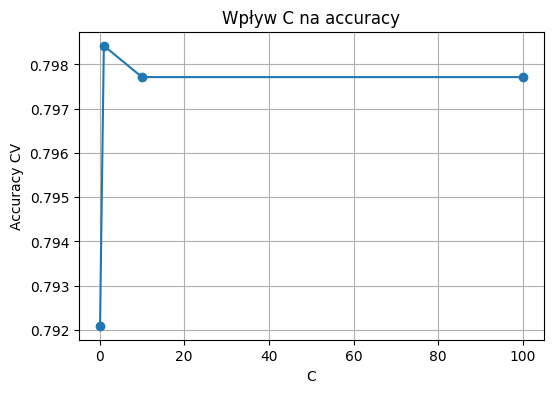

In [16]:
from sklearn.linear_model import LogisticRegression

logitstic_regression_grid = {'C': [0.1, 1, 10, 100],
                            'penalty': ['l1', 'l2']}

logitstic_regression_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=2000) #tu musiałem ustawić solver, żeby wspierał penalty
logitstic_regression_search = GridSearchCV(estimator=logitstic_regression_model,
                                           param_grid=logitstic_regression_grid,
                                           cv=5)

logitstic_regression_search.fit(X_train_scaled, y_train)

all_results.append(evaluate_model(logitstic_regression_search, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression"))
plot_hyperparam_effect(logitstic_regression_search, 'C')

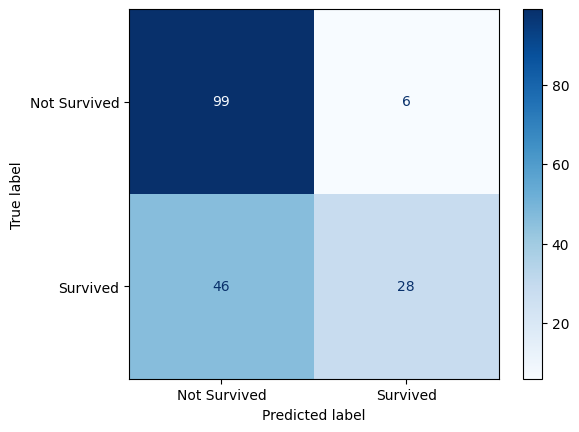

In [27]:
show_confusion_matrix(logitstic_regression_search, X_test, y_test)

Spośród testowanych wartości dla regularyzacji najlepiej wypadło 1.0 (z tego co patrzyłem w dokumentacji to tyle samo co domyślna wartość w sklearn), co oznacza, że lepszy jest model, który bardziej kara się za overfitting (większe C -> większe dopasowanie do danych).

Regresja logistyczna poradziła sobie całkiem nieźle, uzyskując accuracy wyższe niż baseline (79.3%) - co sprawia, że model jest sensowny oraz znacząco wyższe precision (76.8%) mówiące, że raczej model "trafia" z predykcjami. Całkiem wysoki Recall (71.6%) mówi także, że model w miare dobrze poradził sobie ze znalezieniem przypadków pozytywnych.

##Decision Tree

Najlepsze parametry: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5}
Accuracy (train): 0.878
Accuracy (test): 0.788
Precision (test): 0.765
Recall (test): 0.703
F1 (test): 0.732


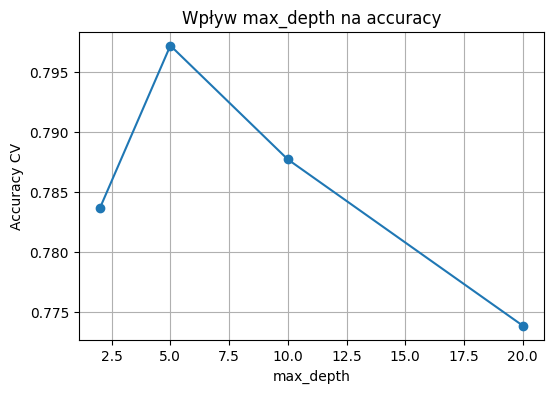

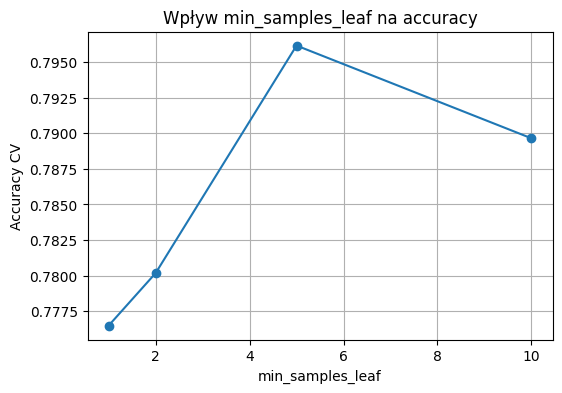

In [25]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_grid = {'max_depth': [2, 5, 10, 20],
                      'criterion': ['gini', 'entropy'],
                      'min_samples_leaf': [1, 2, 5, 10]} #początkowo w min_samples_leaf nie było wartości 10, ale mocno zastanowił mnie wykres idący tylko do góry, ale jak się okazało
                                                         #na szczęście nie w nieskończoność XD

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_search = GridSearchCV(estimator=decision_tree_model,
                                    param_grid=decision_tree_grid,
                                    cv = 5)

decision_tree_search.fit(X_train, y_train)
all_results.append(evaluate_model(decision_tree_search, X_train, y_train, X_test, y_test, "Decision Tree"))
plot_hyperparam_effect(decision_tree_search, 'max_depth')
plot_hyperparam_effect(decision_tree_search, 'min_samples_leaf')

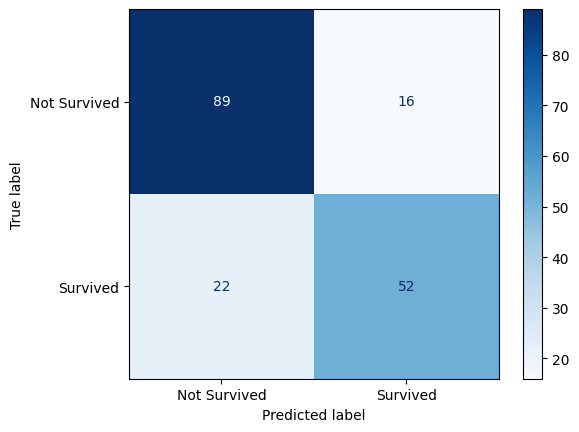

In [26]:
show_confusion_matrix(decision_tree_search, X_test, y_test)

Testowane parametry:

- zbyt duża głębokośc drzewa negatywnie wpływała na accuracy, górka pośród testowanych wartości znajduje się w 5,

- zbyt mała oraz zbyt duża ilość próbek w węźle negatywnie wpływa na accuracy, górka pośród testowanych wartości zanjduje się w 5,

- gini impurity okazało się lepszym przy wyliczaniu zanieczyszczenia węzła niż entropia.

Drzewo decyzyjne uzyskało wysokie accuracy (78,8%) co świadczy o tym, że model jest sensowny, jednak precision (76,5%) jest niższe niż w przypadku regresji logistycznej, co mówi, że drzewo gorzej sobie radzi w trafianiu z predykcjami. Niższy recall także potwierdza, że drzewo gorzej sobie poradziało z odnajdywaniem pozytywnych przypadków.

##Random Forset

Najlepsze parametry: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 200}
Accuracy (train): 0.862
Accuracy (test): 0.799
Precision (test): 0.797
Recall (test): 0.689
F1 (test): 0.739


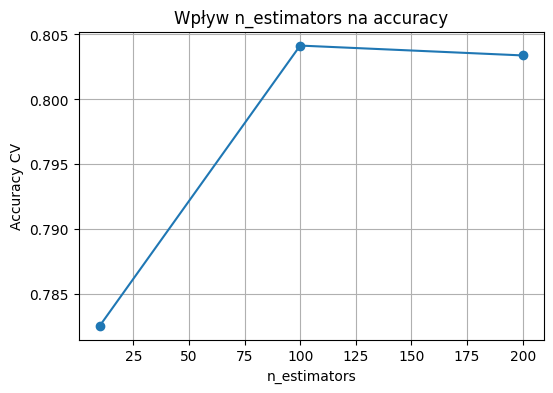

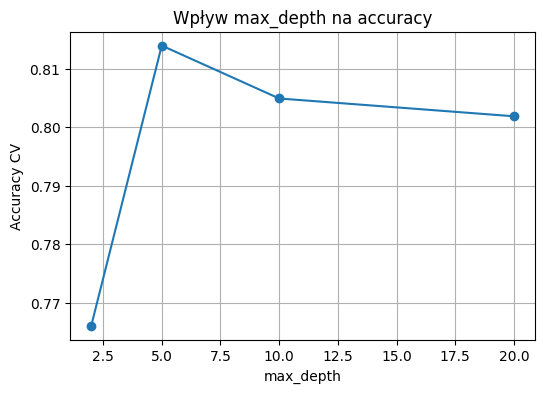

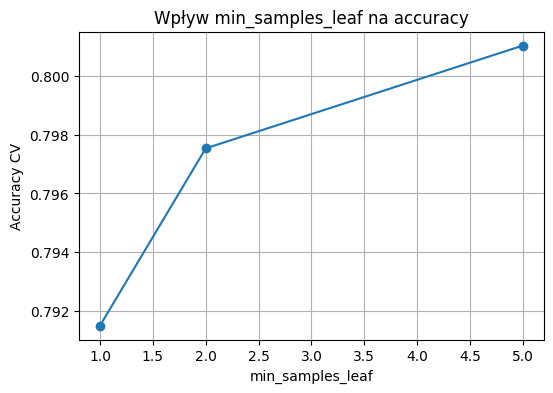

In [20]:
from sklearn.ensemble import RandomForestClassifier

random_forest_grid = {'n_estimators': [10, 100, 200],
                      'max_depth': [2, 5, 10, 20],
                      'criterion': ['gini', 'entropy'],
                      'min_samples_leaf': [1, 2, 5]}

random_forest_model = RandomForestClassifier(random_state=42)
random_forest_search = GridSearchCV(estimator=random_forest_model,
                                    param_grid=random_forest_grid,
                                    cv = 5)

random_forest_search.fit(X_train, y_train)
all_results.append(evaluate_model(random_forest_search, X_train, y_train, X_test, y_test, "Random Forest"))
plot_hyperparam_effect(random_forest_search, 'n_estimators')
plot_hyperparam_effect(random_forest_search, 'max_depth')
plot_hyperparam_effect(random_forest_search, 'min_samples_leaf')

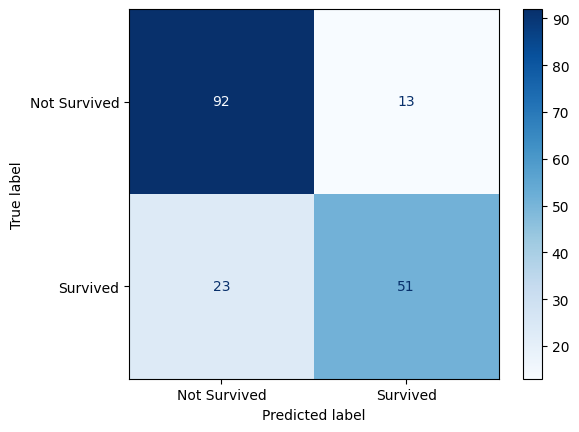

In [23]:
show_confusion_matrix(random_forest_search, X_test, y_test)

Testowane parametry:
- większa liczba drzew (co raczej spodziewane) okazała się pozytywnie wpływać na accuracy modelu,

- najlepszą głębokościa spośród testowanych (tak samo jak w decision tree) okazało się być 5,

- co ciekawe (i trochę zastanawiające) entropia okazała się być lepszym wyznacznikiem zanieczyszczenia węzła (dajacym lepsze accuracy) w tym modelu niz gini impurity,

- najlepszą spośród testowanych ilości próbek w węźle dla modelu okazało się być 2, mimo tego, że 5 najlepiej wpływało na accuracy.

Random forest uzyskał niższe accuracy (79.9%) niż decision tree, jednak znacząco wyższe precision (79.7%), co świadczy, że z testowanych modeli do tej pory poradził sobie najlepiej z "trafianiem". Martwiący jest trochę recall, ponieważ jest najniższy spośród do tej pory przetestowanych modeli.

##KNN

Najlepsze parametry: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}
Accuracy (train): 0.824
Accuracy (test): 0.804
Precision (test): 0.831
Recall (test): 0.662
F1 (test): 0.737


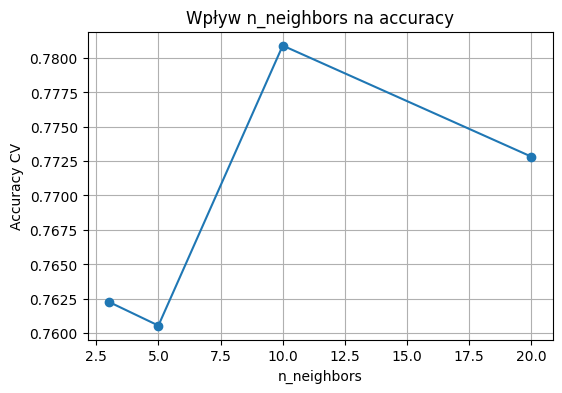

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn_grid = {'n_neighbors': [3, 5, 10, 20],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']}

knn_model = KNeighborsClassifier()
knn_search = GridSearchCV(estimator=knn_model,
                          param_grid=knn_grid,
                          cv = 5)

knn_search.fit(X_train_scaled, y_train)
all_results.append(evaluate_model(knn_search, X_train_scaled, y_train, X_test_scaled, y_test, "KNN"))
plot_hyperparam_effect(knn_search, 'n_neighbors')

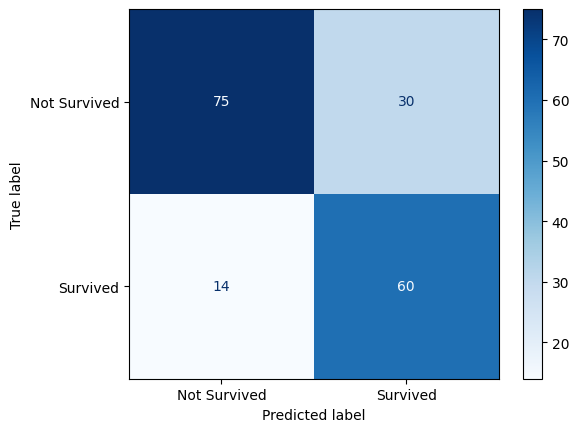

In [22]:
show_confusion_matrix(knn_search, X_test, y_test)

Testowane parametry:
- lepszą metryką okazała się manhattan,
- lepszym sposobem ważenia okazało się być uniform, najpewniej ze względu na możliwość pominięcia lokalnych szumów,
- pośród testowanych liczb sąsiadów najlepsza okazała się 10, co pokazuje, że za mała jak i za duża liczba sąsiadów wpływa negatywnie na model.

Model osiągnął accuracy na poziomie 80.4% co potwierdza jego sensowność (accuracy wyższe niż dla dummy), osiągając przy tym najwyższe precision pośród wszystkich testowanych modeli. Minusem jest zauważalnie niższy recall w stosunku do pozostałych trenowanych modeli.

##Podsumowanie

In [28]:
summary = pd.DataFrame(all_results)[['model', 'train_accuracy', 'test_accuracy',
                                     'test_precision', 'test_recall', 'test_f1']]

In [32]:
summary

,model,train_accuracy,test_accuracy,test_precision,test_recall,test_f1
0,Logistic Regression,0.804775,0.793296,0.768116,0.716216,0.741259
1,KNN,0.824438,0.804469,0.830508,0.662162,0.736842
2,Random Forest,0.862360,0.798883,0.796875,0.689189,0.739130
3,Decision Tree,0.877809,0.787709,0.764706,0.702703,0.732394


Patrząc na ostateczne oceny modeli, możemy zauważyć, że przy Decision Tree doszło najpewniej do przetrenowania (widać sporą różnicę pomiędzy train_accuracy, a test_accuracy) co powoduje, że powinniśmy odrzucić ten model przy wyborze najlepszego do tego zadania. Logistic Regression, KNN i Random Forest (choć w przypadku tego ostatniego też widać dosyć dużą różnicę między train_accuracy, a test_accuracy) wypadają podobnie i tu wybór zależy od tego, która z metryk jest dla nas najważniejsza - jeśli (tak jak wydaję mi się, że powinniśmy uznać) accuracy i precision są dla nas najważniejsze, wybierałbym KNN, jeśli jednak interesuje nas recall to wybierałbym regresję logistyczną. Regresja logistyczna wypada także najlepiej w metryce f1_score, co oznacza, że średnia harmoniczna precision i recall'u jest dla tego modelu najwyższa (co też może być powodem, do jej wyboru).